# Модель для предсказания возраста посетителей сайтов

**Автор:** Денис Куницын

**Дата:** 26 марта 2026

## Цель и задачи 

**Цель:** построить модель многоклассовой клссификации, которая по данным о цифровом поведении пользователя предсказывает его возрастную категорию.

## Задача машинного обучения

- Тип задачи: мультиклассовая классификация
- Целевая переменная: категория возраста пользователя (`age_category`)
- Основная метрика: **F1-macro**.
- Вспомогательные метрики: **precision-macro** и **recall-macro**.

## Данные

Используются таблицы: `users`, `visits`, `ads_activity`, `surf_depth`, `primary_device`, `cloud_usage`.

Краткая структура:
- `users`: `user_id`, `age_category` (0: <18, 1: 18-25, 2: 26-40, 3: 41-55, 4: 56+).
- `visits`: `date`, `daytime`, `session_id`, `user_id`, `website_category`.
- `ads_activity`: `user_id`, `ads_activity`.
- `surf_depth`: `user_id`, `surf_depth`.
- `primary_device`: `user_id`, `primary_device`.
- `cloud_usage`: `user_id`, `cloud_usage`.

## Структура проекта

1. Подготовка среды и библиотек
2. Исследовательский анализ данных
3. Создание единого признакового пространства и новых признаков
4. Формирование выборок
5. Обучение и оценка базовой модели
6. Отбор признаков
7. Подбор гиперпараметров
8. Подготовка финальной модели
9. Подготовка артефактов для внедрения
10. Финальный отчет и выводы

---

## 1. Подготовка среды и библиотек

### 1.1. Загрузка библиотек

In [1]:
requirements_txt = """pandas==2.2.3
numpy==2.0.2
matplotlib==3.9.4
phik==0.12.5
seaborn==0.13.2
scikit-learn==1.5.2
joblib==1.4.2
"""

with open('requirements.txt', 'w', encoding='utf-8') as f:
    f.write(requirements_txt)

!pip -q install -r requirements.txt

You should consider upgrading via the '/Users/dkunicyn/Documents/to-future/yeti/venv/bin/python -m pip install --upgrade pip' command.


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import phik
import joblib
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectPercentile, f_classif
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix
from sklearn.metrics import make_scorer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

### 1.2. Загрузка данных и первичное знакомство

In [3]:
# Константы для воспроизводимости и контроля эксперимента
RANDOM_STATE = 42
TEST_SIZE = 0.25
N_SPLITS = 5
F1_TARGET = 0.75

DATASETS = json.loads(os.getenv('DATASETS'))

BASE_URL = os.getenv('BASE_URL_DATASETS')

In [4]:
users = pd.read_csv(BASE_URL + DATASETS['users'])
visits = pd.read_csv(BASE_URL + DATASETS['visits'])
ads_activity = pd.read_csv(BASE_URL + DATASETS['ads_activity'])
surf_depth = pd.read_csv(BASE_URL + DATASETS['surf_depth'])
primary_device = pd.read_csv(BASE_URL + DATASETS['primary_device'])
cloud_usage = pd.read_csv(BASE_URL + DATASETS['cloud_usage'])

tables = {
    'users': users,
    'visits': visits,
    'ads_activity': ads_activity,
    'surf_depth': surf_depth,
    'primary_device': primary_device,
    'cloud_usage': cloud_usage,
}

{name: df.shape for name, df in tables.items()}

{'users': (5913, 2),
 'visits': (1065745, 5),
 'ads_activity': (5826, 2),
 'surf_depth': (5715, 2),
 'primary_device': (5669, 2),
 'cloud_usage': (5680, 2)}

In [5]:
def quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    return pd.DataFrame({
        'table': [name],
        'rows': [len(df)],
        'cols': [df.shape[1]],
        'missing_total': [int(df.isna().sum().sum())],
        'missing_percent': [round(df.isna().mean().mean() * 100, 2)],
        'duplicates': [int(df.duplicated().sum())],
        'duplicates_percent': [round(df.duplicated().mean() * 100, 2)],
    })

quality_df = pd.concat([quality_report(df, name) for name, df in tables.items()], ignore_index=True)
quality_df.sort_values('table').reset_index(drop=True)

,table,rows,cols,missing_total,missing_percent,duplicates,duplicates_percent
0,ads_activity,5826,2,0,0.0,233,4.00
1,cloud_usage,5680,2,0,0.0,0,0.00
2,primary_device,5669,2,0,0.0,0,0.00
3,surf_depth,5715,2,0,0.0,0,0.00
4,users,5913,2,0,0.0,87,1.47
5,visits,1065745,5,0,0.0,15750,1.48


#### Выводы

Датафрейм содержит всего 5913 пользователей, среди которых 87 (1.5%) - дубликаты.

Датасеты не содержат явных пропусков. Однако, стоит исследовать данные на наличие значений-индикаторов пропусков.

Столбцы `ads_activity`, `users` и `visits` содержат явные дубликаты.

---

## 2. Исследовательский анализ данных

### 2.1. Анализ целевой переменной

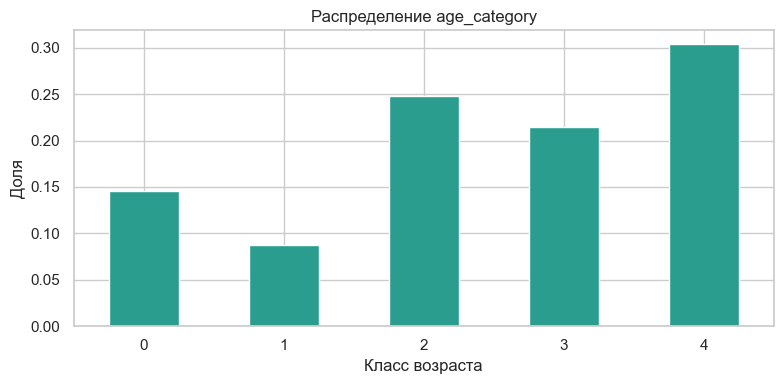

In [6]:
# Распределение целевой переменной
fig, ax = plt.subplots(figsize=(8, 4))
users['age_category'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=ax, color='#2a9d8f', rot=0)
ax.set_title('Распределение age_category')
ax.set_xlabel('Класс возраста')
ax.set_ylabel('Доля')
plt.tight_layout()
plt.show()

Наблюдается умеренный дисбаланс классов - этот момент стоит учесть при анализе метрик.

---

### 2.2. Анализ признаков

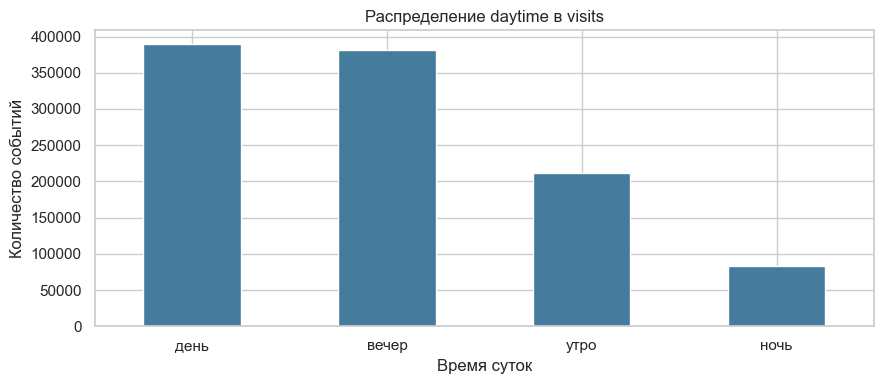

In [7]:
# Анализ распределения активности по времени суток
fig, ax = plt.subplots(figsize=(9, 4))
visits['daytime'].value_counts().plot(kind='bar', ax=ax, color='#457b9d', rot=0)
ax.set_title('Распределение daytime в visits')
ax.set_xlabel('Время суток')
ax.set_ylabel('Количество событий')
plt.tight_layout()
plt.show()

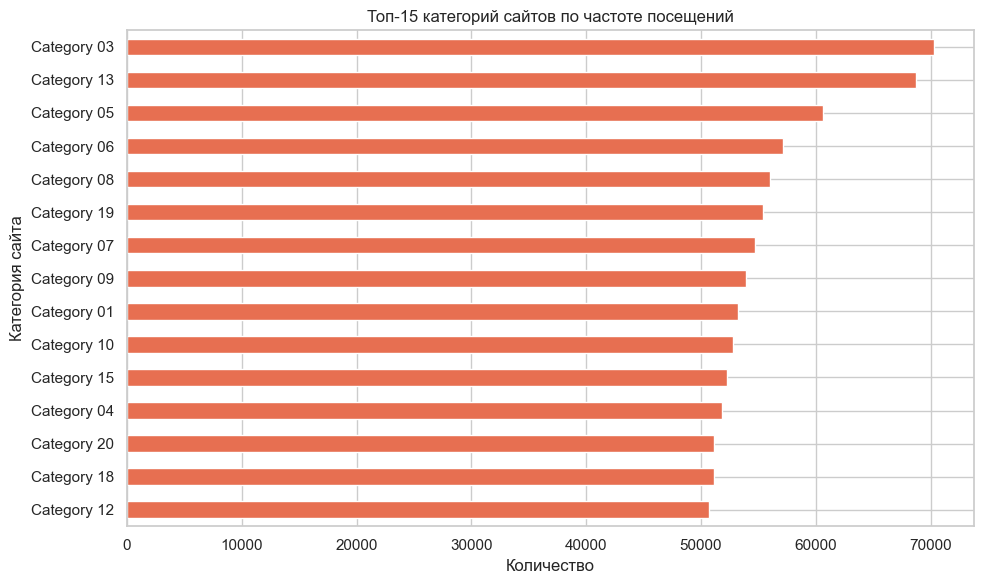

In [8]:
# Топ категорий сайтов
top_sites = visits['website_category'].value_counts().head(15).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
top_sites.plot(kind='barh', ax=ax, color='#e76f51')
ax.set_title('Топ-15 категорий сайтов по частоте посещений')
ax.set_xlabel('Количество')
ax.set_ylabel('Категория сайта')
plt.tight_layout()
plt.show()

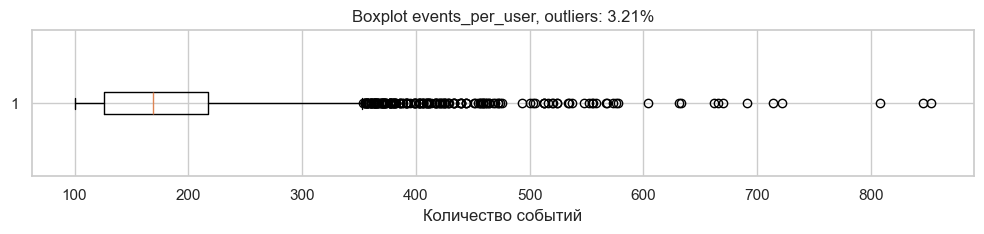

In [9]:
# Проверка выбросов по числу событий на пользователя (IQR)
events_per_user = visits.groupby('user_id').size().rename('events_count')
q1, q3 = events_per_user.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_pct = ((events_per_user < lower) | (events_per_user > upper)).mean() * 100

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.boxplot(events_per_user, vert=False)
ax.set_title(f'Boxplot events_per_user, outliers: {outliers_pct:.2f}%')
ax.set_xlabel('Количество событий')
plt.tight_layout()
plt.show()

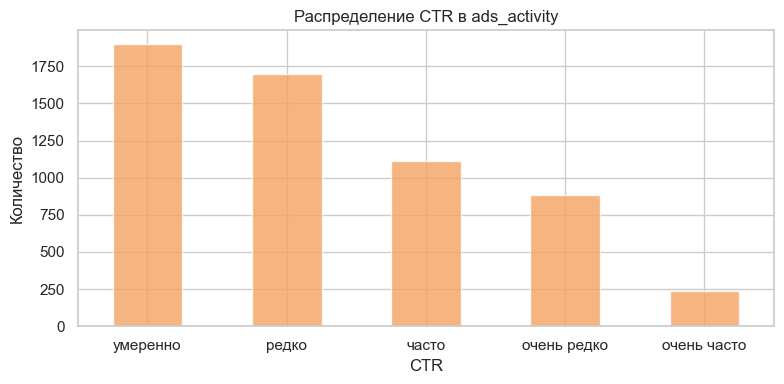

In [10]:
# Распределение характеристики CTR в ads_activity
fig, ax = plt.subplots(figsize=(8, 4))
ads_activity['ads_activity'].value_counts().plot(kind='bar', ax=ax, color='#f4a261', alpha=0.8, rot=0)
ax.set_title('Распределение CTR в ads_activity')
ax.set_xlabel('CTR')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

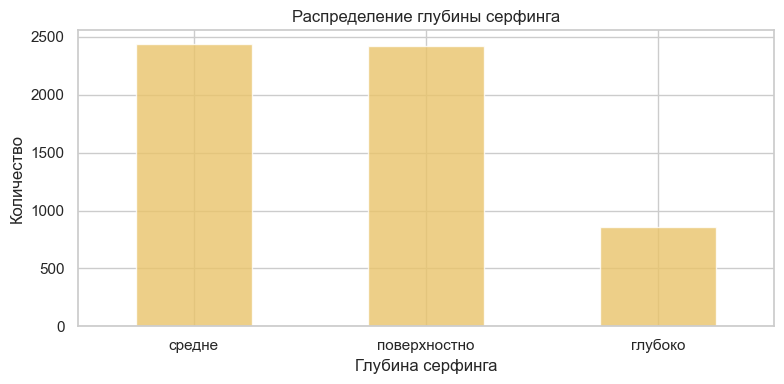

In [11]:
# Распределение глубины серфинга
fig, ax = plt.subplots(figsize=(8, 4))
surf_depth['surf_depth'].value_counts().plot(kind='bar', ax=ax, color='#e9c46a', alpha=0.8, rot=0)
ax.set_title('Распределение глубины серфинга')
ax.set_xlabel('Глубина серфинга')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

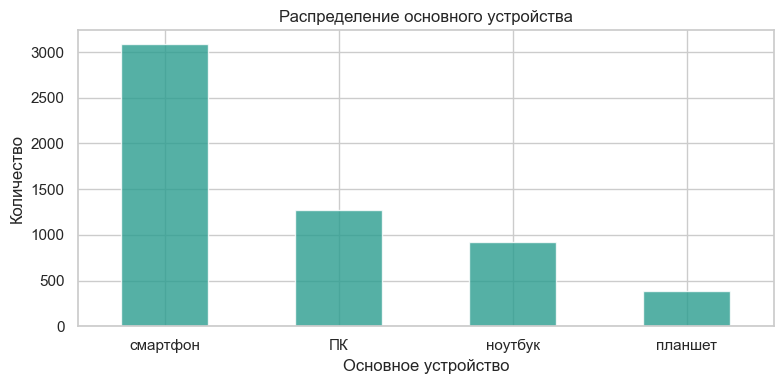

In [12]:
# Распределение основного устройства
fig, ax = plt.subplots(figsize=(8, 4))
primary_device['primary_device'].value_counts().plot(kind='bar', ax=ax, color='#2a9d8f', alpha=0.8, rot=0)
ax.set_title('Распределение основного устройства')
ax.set_xlabel('Основное устройство')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

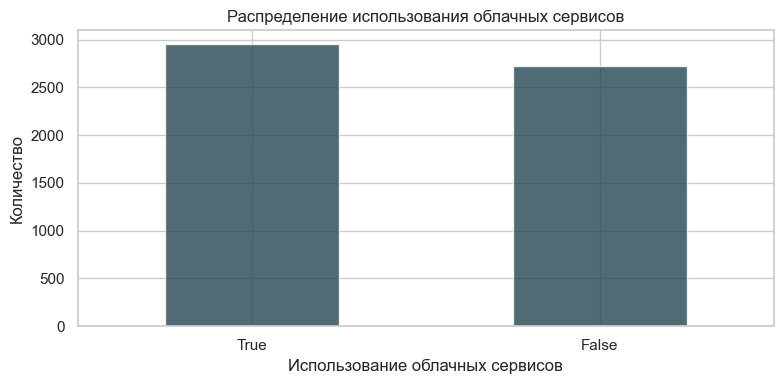

In [13]:
# Распределение использования облачных сервисов
fig, ax = plt.subplots(figsize=(8, 4))
cloud_usage['cloud_usage'].value_counts().plot(kind='bar', ax=ax, color='#264653', alpha=0.8, rot=0)
ax.set_title('Распределение использования облачных сервисов')
ax.set_xlabel('Использование облачных сервисов')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

На данном этапе из избыточных признаков можно выделить лишь идентификаторы пользователей в каждом из датасетов. Остальные признаки могут оказывать влияние на целевую переменную, что проверим после создания единого признакового пространства.

Выбросы по активности пользователей присутствуют, но удалять их не будем: это может быть полезный поведенческий паттерн. 

---

### 2.4. Анализ пропущенных значений

Первычный анализ данных показал, что признаки не содержат явных пропусков. Также, построение графиков распределения отразило отсутствие значений-индикаторов пропусков. 

---

### 2.5. Обработка дубликатов

Первичный анализ данных показал наличие дубликатов в столбцах `ads_activity`, `users` и `visits`. Ни в одном из столбцов количество дубликатов не превышает 5% от всех значений. 

Дубликаты негативно влияют на обучение модели и увеличиют значение повторяющегося паттерна, поэтому данные необходимо очистить.

In [14]:
# Очистка дубликатов
for name, df in tables.items():
    before = len(df)
    tables[name] = df.drop_duplicates().reset_index(drop=True)
    after = len(tables[name])
    print(f'{name}: удалено {before - after} дубликатов')

users: удалено 87 дубликатов
visits: удалено 15750 дубликатов
ads_activity: удалено 233 дубликатов
surf_depth: удалено 0 дубликатов
primary_device: удалено 0 дубликатов
cloud_usage: удалено 0 дубликатов


Дубликаты успешно очищены.

---

#### Выводы по итогам EDA

1. Целевая переменная (age_category) распределена неравномерно, с преобладанием категорий 2 (26-40 лет) и 4 (56+ лет). Это может потребовать использования методов балансировки классов при обучении модели.

2. Активность пользователей по времени суток показывает, что большинство событий происходит в дневное и вечернее время. Это может быть связано с рабочими часами и привычками пользователей.

3. Число событий на пользователя имеет выбросы, что может потребовать применения методов обработки выбросов. 

4. Анализ корреляции признаков будет проведен после создания единого признакового пространства. 

---

## 3. Создание единого признакового пространства

### 3.1. Создание признакового пространства

In [15]:
def build_feature_space(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    visits = visits.copy()
    visits['date'] = pd.to_datetime(visits['date'], errors='coerce')
    
    # Агрегация активности по пользователю
    user_activity = visits.groupby('user_id').agg(
        events_count=('session_id', 'size'),
        unique_sessions=('session_id', 'nunique'),
        unique_days=('date', 'nunique')
    )
    user_activity['avg_sessions_per_day'] = (
        user_activity['unique_sessions'] / user_activity['unique_days'].replace(0, np.nan)
    )
    user_activity['avg_sessions_per_day'] = user_activity['avg_sessions_per_day'].fillna(0)

    # Доля посещений по категориям сайтов и времени суток
    site_share = pd.crosstab(visits['user_id'], visits['website_category'], normalize='index')
    site_share = site_share.iloc[:, :-1]  # Удаляем последний столбец для избежания дамми-ловушки
    site_share = site_share.add_prefix('share_site_')

    # Доля посещений по времени суток
    daytime_share = pd.crosstab(visits['user_id'], visits['daytime'], normalize='index')
    daytime_share = daytime_share.iloc[:, :-1]  # Удаляем последний столбец для избежания дамми-ловушки
    daytime_share = daytime_share.add_prefix('share_daytime_')

    # Выделение наиболее активного времени суток для каждого пользователя
    most_active_daytime = (
        visits.groupby(['user_id', 'daytime']).size().rename('cnt').reset_index()
        .sort_values(['user_id', 'cnt'], ascending=[True, False])
        .drop_duplicates('user_id')[['user_id', 'daytime']]
        .rename(columns={'daytime': 'most_active_daytime'})
    )

    # Сбор всех признаков в одну таблицу
    features = user_activity.join(site_share, how='left').join(daytime_share, how='left')
    features = features.reset_index()

    for df in [ads_activity, surf_depth, primary_device, cloud_usage, most_active_daytime]:
        features = features.merge(df, on='user_id', how='left')

    target = users[['user_id', 'age_category']].copy()
    features = features.merge(target, on='user_id', how='left')

    return features

In [16]:
dataset = build_feature_space(**tables)

dataset.head()

,user_id,events_count,unique_sessions,unique_days,avg_sessions_per_day,share_site_Category 01,share_site_Category 02,share_site_Category 03,share_site_Category 04,share_site_Category 05,share_site_Category 06,share_site_Category 07,share_site_Category 08,share_site_Category 09,share_site_Category 10,share_site_Category 11,share_site_Category 12,share_site_Category 13,share_site_Category 14,share_site_Category 15,share_site_Category 16,share_site_Category 17,share_site_Category 18,share_site_Category 19,share_daytime_вечер,share_daytime_день,share_daytime_ночь,ads_activity,surf_depth,primary_device,cloud_usage,most_active_daytime,age_category
0,0010-5cf8f6b38a7b6c70a021-009dbcda,546,546,14,39.000000,0.029304,0.000000,0.062271,0.042125,0.032967,0.053114,0.047619,0.075092,0.023810,0.040293,0.056777,0.078755,0.021978,0.034799,0.027473,0.060440,0.051282,0.078755,0.091575,0.413919,0.326007,0.095238,умеренно,средне,ноутбук,True,вечер,0
1,0013-4ae5f7d127b91a3fb0f8-ba59f141,185,185,14,13.214286,0.081081,0.059459,0.027027,0.037838,0.081081,0.037838,0.048649,0.097297,0.059459,0.059459,0.070270,0.000000,0.064865,0.037838,0.016216,0.043243,0.064865,0.086486,0.005405,0.275676,0.372973,0.086486,умеренно,средне,планшет,False,день,4
2,0014-d3032d60979a8d2b3077-f09bdce8,117,117,14,8.357143,0.008547,0.017094,0.034188,0.059829,0.068376,0.051282,0.042735,0.017094,0.034188,0.051282,0.000000,0.059829,0.170940,0.068376,0.059829,0.017094,0.076923,0.025641,0.102564,0.307692,0.384615,0.094017,очень редко,поверхностно,NaN,False,день,4
3,001a-eee53e44f848608779b0-78704a67,287,287,14,20.500000,0.066202,0.045296,0.034843,0.076655,0.034843,0.031359,0.041812,0.045296,0.045296,0.041812,0.048780,0.066202,0.000000,0.097561,0.041812,0.031359,0.045296,0.073171,0.073171,0.414634,0.334495,0.108014,очень редко,поверхностно,планшет,False,вечер,0
4,002c-40a064b12e1217e12207-a56eaf3b,490,490,14,35.000000,0.000000,0.053061,0.071429,0.061224,0.040816,0.038776,0.059184,0.018367,0.059184,0.065306,0.038776,0.085714,0.169388,0.000000,0.044898,0.040816,0.034694,0.012245,0.051020,0.295918,0.383673,0.069388,умеренно,средне,ПК,True,день,4


In [17]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 5826 non-null   object 
 1   events_count            5826 non-null   int64  
 2   unique_sessions         5826 non-null   int64  
 3   unique_days             5826 non-null   int64  
 4   avg_sessions_per_day    5826 non-null   float64
 5   share_site_Category 01  5826 non-null   float64
 6   share_site_Category 02  5826 non-null   float64
 7   share_site_Category 03  5826 non-null   float64
 8   share_site_Category 04  5826 non-null   float64
 9   share_site_Category 05  5826 non-null   float64
 10  share_site_Category 06  5826 non-null   float64
 11  share_site_Category 07  5826 non-null   float64
 12  share_site_Category 08  5826 non-null   float64
 13  share_site_Category 09  5826 non-null   float64
 14  share_site_Category 10  5826 non-null   

После создания единого признакового пространства, некоторые признаки образовали пропуски. Скорее всего это связано с неизвестностью информации о пользователе. Поэтому заменим пропуски в категориальных признаках на значение-индикатор пропуска.

In [18]:
# Превращение cloud_usage в числовой признак (0/1)
dataset['cloud_usage'] = dataset['cloud_usage'].map({True: 1, False: 0}).fillna(-1).astype(int)

# Замена пропусков в признаках на 0 (для числовых) и 'неизвестно' (для категориальных)
for col in dataset.columns:
    if dataset[col].dtype in ['float64', 'int64']:
        dataset[col] = dataset[col].fillna(-1)
    else:
        dataset[col] = dataset[col].fillna('неизвестно')

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 5826 non-null   object 
 1   events_count            5826 non-null   int64  
 2   unique_sessions         5826 non-null   int64  
 3   unique_days             5826 non-null   int64  
 4   avg_sessions_per_day    5826 non-null   float64
 5   share_site_Category 01  5826 non-null   float64
 6   share_site_Category 02  5826 non-null   float64
 7   share_site_Category 03  5826 non-null   float64
 8   share_site_Category 04  5826 non-null   float64
 9   share_site_Category 05  5826 non-null   float64
 10  share_site_Category 06  5826 non-null   float64
 11  share_site_Category 07  5826 non-null   float64
 12  share_site_Category 08  5826 non-null   float64
 13  share_site_Category 09  5826 non-null   float64
 14  share_site_Category 10  5826 non-null   

Единое признаковое пространство успешно создано.

---

### 3.2. Дополнение к EDA: анализ корреляции признаков

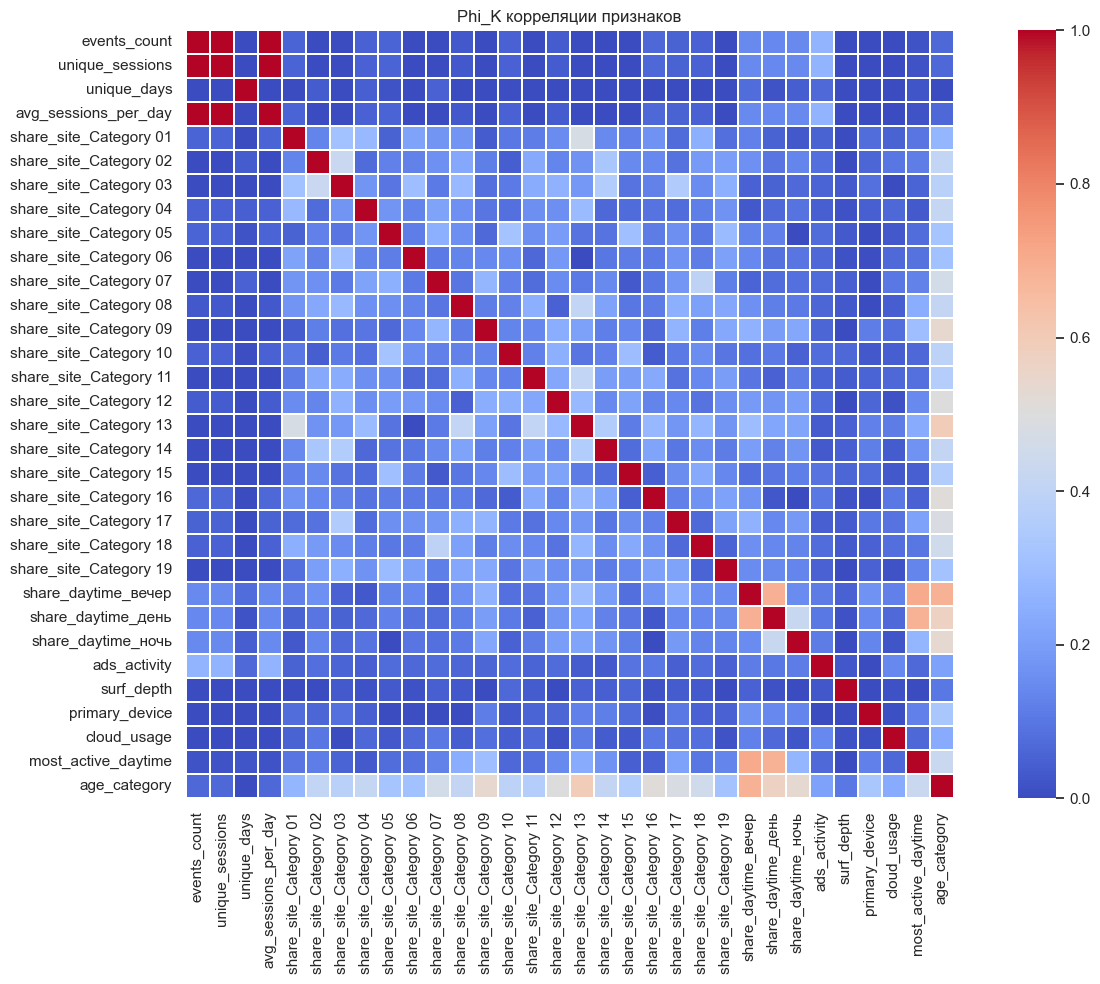

In [19]:
# Убираем идентификатор, чтобы не искажать интерпретацию
corr_data = dataset.drop(columns=['user_id'], errors='ignore').copy()

# Для phik укажем числовые признаки как интервальные
interval_cols = corr_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Матрица Phi_K
phik_corr = corr_data.phik_matrix(interval_cols=interval_cols)

# Тепловая карта
plt.figure(figsize=(14, 10))
sns.heatmap(
    phik_corr,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    square=True,
    linewidths=0.3
)
plt.title('Phi_K корреляции признаков')
plt.tight_layout()
plt.show()

In [20]:
# Признаки с наибольшей корреляцией с целевой переменной
top_corr_with_target = (
    phik_corr['age_category']
    .drop(index='age_category', errors='ignore')
    .sort_values(ascending=False)
)

print('Топ признаков по корреляции с age_category (Phi_K):')
display(top_corr_with_target.head(10).to_frame('phik_corr'))

Топ признаков по корреляции с age_category (Phi_K):


,phik_corr
share_daytime_вечер,0.686111
share_site_Category 13,0.595733
share_daytime_день,0.566752
share_site_Category 09,0.536089
share_daytime_ночь,0.532861
share_site_Category 16,0.507852
share_site_Category 12,0.503128
share_site_Category 17,0.482861
share_site_Category 07,0.460505
share_site_Category 18,0.452656


In [21]:
# Поиск мультиколлинеарных признаков по Phi_K
PHIK_THRESHOLD = 0.85

# Исключаем target, чтобы анализировать только признаки
phik_features = phik_corr.drop(index='age_category', columns='age_category', errors='ignore')

# Берем только верхний треугольник матрицы (без диагонали)
upper = phik_features.where(np.triu(np.ones(phik_features.shape), k=1).astype(bool))

# Формируем таблицу пар с высокой связью
high_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'phik'})
    .query('phik >= @PHIK_THRESHOLD')
    .sort_values('phik', ascending=False)
    .reset_index(drop=True)
)

print(f'Порог Phi_K: {PHIK_THRESHOLD}')
if high_pairs.empty:
    print('Мультиколлинеарных пар не найдено.')
else:
    # Рассчитываем абсолютную корреляцию признаков с target (Phi_K)
    corr_with_target = phik_corr['age_category'].drop(index='age_category', errors='ignore')

    # Выбираем для удаления признак с меньшей по модулю корреляцией с целевой переменной
    decisions = []
    for _, row in high_pairs.iterrows():
        f1 = row['feature_1']
        f2 = row['feature_2']
        c1 = abs(corr_with_target.get(f1, 0))
        c2 = abs(corr_with_target.get(f2, 0))
        # Если оба отсутствуют в corr_with_target, по умолчанию удаляем второй (f2)
        if c1 >= c2:
            drop = f2
        else:
            drop = f1
        decisions.append({'feature_1': f1, 'feature_2': f2, 'phik': row['phik'], 'corr_with_target_1': c1, 'corr_with_target_2': c2, 'drop_candidate': drop})

    decisions_df = pd.DataFrame(decisions)
    display(decisions_df)

    # Окончательные кандидаты на удаление — уникальные значения столбца drop_candidate
    drop_candidates = decisions_df['drop_candidate'].unique().tolist()
    print('\nКандидаты на удаление:')
    print(drop_candidates)

Порог Phi_K: 0.85


,feature_1,feature_2,phik,corr_with_target_1,corr_with_target_2,drop_candidate
0,events_count,unique_sessions,1.0,0.065297,0.065297,unique_sessions
1,events_count,avg_sessions_per_day,1.0,0.065297,0.065297,avg_sessions_per_day
2,unique_sessions,avg_sessions_per_day,1.0,0.065297,0.065297,avg_sessions_per_day



Кандидаты на удаление:
['unique_sessions', 'avg_sessions_per_day']


In [22]:
print(f'Количество признаков до удаления мультиколлинеарных: {dataset.shape[1]}')

# Удаление мультиколлинеарных признаков
dataset = dataset.drop(columns=drop_candidates, errors='ignore')
print(f'Количество признаков после удаления мультиколлинеарных: {dataset.shape[1]}')

Количество признаков до удаления мультиколлинеарных: 33
Количество признаков после удаления мультиколлинеарных: 31


#### Выводы

Наиболее коррелирующие признаки с целевой переменной - признаки, указывающие на основное время активности, долю посещений по вермени суток и некоторые анонимизированные категории сайтов.

Корреляционный анализ выявил 3 мультиколлинеарных признака. Мультиколлинеарные признаки удалены в сответствие с корреляцией с целевой переменной.

Всего признаков до предобработки кодировщиками - 31.

---

## 4. Формирование выборок

In [23]:
X = dataset.drop(columns=['age_category', 'user_id'])
y = dataset['age_category']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=TEST_SIZE, shuffle=True, random_state=RANDOM_STATE)

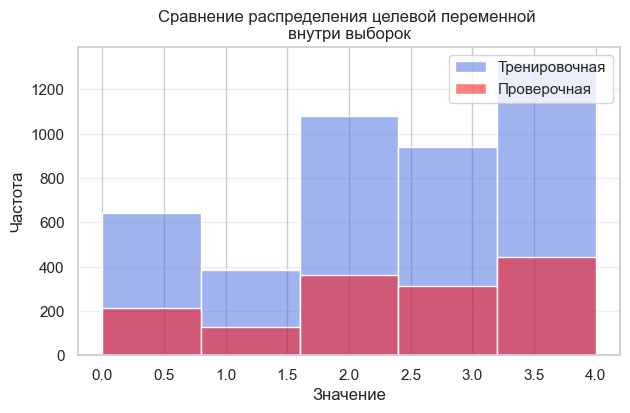

In [24]:
# Анализ распределения целевой переменной 

plt.figure(figsize=(7, 4))

sns.histplot(y_train, bins=5, alpha=0.5, label='Тренировочная', color='royalblue', stat='count')
sns.histplot(y_test, bins=5, alpha=0.5, label='Проверочная', color='red', stat='count')
plt.grid(axis='y', alpha=0.3)
plt.xlabel('Значение')
plt.ylabel('Частота')

plt.title('Сравнение распределения целевой переменной \nвнутри выборок')
plt.legend(loc='upper right')

plt.show()

Целевая переменная равномерно распределилась по двум выборкам. 

Каждая из выборок содержит уникальных пользователей, потому что в датасете отсутствовали дубликаты. 

---

## 5. Обучение и оценка базовой модели

### 5.1. Создание пайплайна предобработки

In [25]:
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='неизвестно')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numerical_features),
    ('cat', categorical_pipe, categorical_features)
])

### 5.2. Обучение и оценка базовых архитектур

Сравниваем `DummyClassifier`, `LogisticRegression`, `SVC` на кросс-валидации. 

In [26]:
def build_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('variance_threshold', VarianceThreshold(threshold=0.01)),
        ('selector', SelectPercentile(score_func=f_classif, percentile=100)),
        ('model', model)
    ])

models = {
    'DummyClassifier': DummyClassifier(strategy='prior', random_state=RANDOM_STATE),
    'LogisticRegression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=3000,
        class_weight='balanced',
        multi_class='multinomial'
    ),
    'SVC': SVC(
        random_state=RANDOM_STATE,
        probability=False,
        class_weight='balanced'
    ),
}

scoring = {
    'f1_macro': make_scorer(f1_score, average='macro'),
    'precision_macro': make_scorer(precision_score, average='macro', zero_division=0),
    'recall_macro': make_scorer(recall_score, average='macro', zero_division=0),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

rows = []
for model_name, model in models.items():
    pipe = build_pipeline(model)
    cv_res = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    rows.append({
        'model': model_name,
        'cv_f1_macro_mean': round(cv_res['test_f1_macro'].mean(), 2),
        'cv_f1_macro_std': round(cv_res['test_f1_macro'].std(), 4),
        'cv_precision_macro_mean': round(cv_res['test_precision_macro'].mean(), 2),
        'cv_recall_macro_mean': round(cv_res['test_recall_macro'].mean(), 2),
    })

cv_table = pd.DataFrame(rows).sort_values('cv_f1_macro_mean', ascending=False).reset_index(drop=True)
cv_table

/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.p

,model,cv_f1_macro_mean,cv_f1_macro_std,cv_precision_macro_mean,cv_recall_macro_mean
0,SVC,0.89,0.0062,0.88,0.89
1,LogisticRegression,0.81,0.0021,0.80,0.82
2,DummyClassifier,0.09,0.0001,0.06,0.20


#### Выбор модели 

Архитектура с моделью `SVC` получила лучшую оценку основной метрики `F1_macro` на кросс-валидации. Далее для подбора гиперпараметров будет использоваться именно эта модель.

---

## 6. Подбор гиперпараметров

In [27]:
best_architecture = cv_table[cv_table['model'].isin(['LogisticRegression', 'SVC'])].iloc[0]['model']
best_architecture

'SVC'

In [28]:
if best_architecture == 'LogisticRegression':
    estimator = build_pipeline(
        LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=4000,
            class_weight='balanced',
            multi_class='multinomial'
        )
    )
    param_grid = {
        'variance_threshold__threshold': [0, 0.01, 0.02, 0.05, 0.1],
        'selector__percentile': [20, 40, 60, 80, 100],
        'model__C': [0.1, 1.0, 3.0, 10.0],
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'newton-cg'],
    }
else:
    estimator = build_pipeline(
        SVC(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            probability=False
        )
    )
    param_grid = [
        {
            'variance_threshold__threshold': [0, 0.01, 0.02, 0.05, 0.1],
            'selector__percentile': [20, 40, 60, 80, 100],
            'model__kernel': ['linear'],
            'model__C': [0.3, 1.0, 3.0, 10.0],
        },
        {
            'variance_threshold__threshold': [0, 0.01, 0.02, 0.05, 0.1],
            'selector__percentile': [20, 40, 60, 80, 100],
            'model__kernel': ['rbf'],
            'model__C': [0.3, 1.0, 3.0],
            'model__gamma': ['scale', 'auto'],
        },
        {
            'variance_threshold__threshold': [0, 0.01, 0.02, 0.05, 0.1],
            'selector__percentile': [20, 40, 60, 80, 100],
            'model__kernel': ['poly'],
            'model__C': [0.3, 1.0, 3.0],
            'model__degree': [2, 3, 4],
            'model__gamma': ['scale', 'auto'],
        },
    ]

grid = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring=make_scorer(f1_score, average='macro'),
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_cv_f1 = grid.best_score_
print(f'Лучшее CV F1_macro: {best_cv_f1:.4f}')
print(f'Лучшие параметры: {grid.best_params_}')

/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/dkunicyn/Documents/to-future/yeti/venv/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:242: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all

Лучшее CV F1_macro: 0.8896
Лучшие параметры: {'model__C': 3.0, 'model__gamma': 'scale', 'model__kernel': 'rbf', 'selector__percentile': 100, 'variance_threshold__threshold': 0.1}


---

## 7. Подготовка финальной модели

In [29]:
# Метрики на тестовой выборке
y_pred_test = best_model.predict(X_test)

test_metrics = pd.DataFrame([{
    'test_f1_macro': f1_score(y_test, y_pred_test, average='macro'),
    'test_precision_macro': precision_score(y_test, y_pred_test, average='macro', zero_division=0),
    'test_recall_macro': recall_score(y_test, y_pred_test, average='macro', zero_division=0),
    'target_f1_macro': F1_TARGET,
}])

test_metrics

,test_f1_macro,test_precision_macro,test_recall_macro,target_f1_macro
0,0.890673,0.888427,0.893113,0.75


Основная метрика `test_f1_macro` выше пороговой `target_f1_macro`.

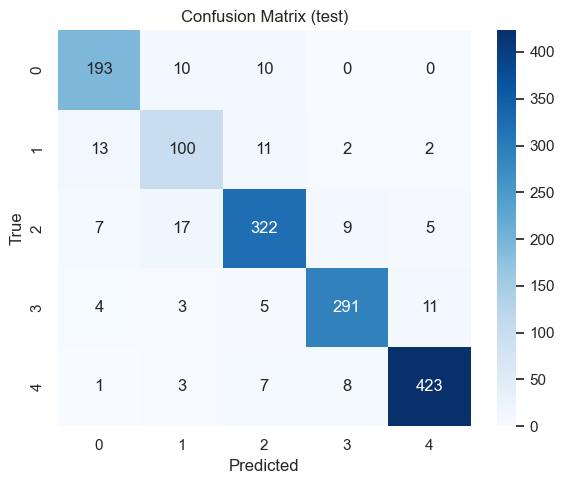

In [30]:
# Матрица ошибок для интерпретации результатов по классам
cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix (test)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

Линия по диагонале намного темнее остальных областей. Это отражает отличную способность модели предсказывать возрастную группу пользователя.

In [31]:
class_report_df = pd.DataFrame(classification_report(y_test, y_pred_test, output_dict=True)).T
class_report_df

,precision,recall,f1-score,support
0,0.885321,0.906103,0.895592,213.000000
1,0.751880,0.781250,0.766284,128.000000
2,0.907042,0.894444,0.900699,360.000000
3,0.938710,0.926752,0.932692,314.000000
4,0.959184,0.957014,0.958097,442.000000
accuracy,0.912148,0.912148,0.912148,0.912148
macro avg,0.888427,0.893113,0.890673,1457.000000
weighted avg,0.912878,0.912148,0.912451,1457.000000


Модель отлично распознает все классы. Небольшая просадка в точности (`precision`) и полносте (`recall`) наблюдается у класса возрастной группы `18-25`, что закономерно - это класс с наименьшей долей пользователей в данных.

In [32]:
# Если pipe еще не обучен, обучаем на train
if not hasattr(pipe.named_steps['selector'], 'scores_'):
    pipe.fit(X_train, y_train)

# Достаем шаги пайплайна
preprocessor = pipe.named_steps['preprocessor']
vt = pipe.named_steps['variance_threshold']
selector = pipe.named_steps['selector']

# Имена признаков после ColumnTransformer
feature_names_after_preprocessor = preprocessor.get_feature_names_out()

# Имена признаков после VarianceThreshold
vt_mask = vt.get_support()
feature_names_after_vt = feature_names_after_preprocessor[vt_mask]

# Имена признаков, прошедших selector
selector_mask = selector.get_support()
selected_feature_names = feature_names_after_vt[selector_mask]

# Оценки важности selector (ANOVA F-score) и p-value
selected_scores = selector.scores_[selector_mask]
selected_pvalues = selector.pvalues_[selector_mask]

# Таблица важности
feature_importance_df = (
    pd.DataFrame({
        'feature': selected_feature_names,
        'selector_score': selected_scores
    })
    .sort_values('selector_score', ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.index = feature_importance_df.index + 1
feature_importance_df.index.name = 'rank'
feature_importance_df.head(10)

,feature,selector_score
rank,,
1,num__share_daytime_вечер,711.269807
2,cat__most_active_daytime_день,387.534663
3,num__share_site_Category 09,370.306239
4,num__share_daytime_день,365.543994
5,num__share_site_Category 13,354.273927
6,num__share_daytime_ночь,347.041667
7,num__share_site_Category 16,291.648964
8,num__share_site_Category 12,282.998036
9,num__share_site_Category 17,275.393943


Основными признаками для определения возрастной группы стали признаки, указывающие на основное время активности, долю посещений по времени суток и некоторые анонимизированные категории сайтов.

---

## 8. Подготовка артефактов для внедрения

In [33]:
os.makedirs('artifacts', exist_ok=True)

joblib.dump(best_model, 'artifacts/age_model_pipeline.joblib')
joblib.dump(
    {
        'random_state': RANDOM_STATE,
        'test_size': TEST_SIZE,
        'n_splits': N_SPLITS,
        'best_architecture': best_architecture,
        'best_params': grid.best_params_,
        'best_cv_f1_macro': float(best_cv_f1),
        'test_f1_macro': float(test_metrics['test_f1_macro'].iloc[0]),
    },
    'artifacts/model_metadata.joblib'
)

['artifacts/model_metadata.joblib']

In [34]:
feature_builder_code = """import numpy as np


def build_feature_space(users, visits, ads_activity, surf_depth, primary_device, cloud_usage):
    visits = visits.copy()
    visits['date'] = pd.to_datetime(visits['date'], errors='coerce')

    # Агрегация активности по пользователю
    user_activity = visits.groupby('user_id').agg(
        events_count=('session_id', 'size'),
        unique_sessions=('session_id', 'nunique'),
        unique_days=('date', 'nunique')
    )
    user_activity['avg_sessions_per_day'] = (
        user_activity['unique_sessions'] / user_activity['unique_days'].replace(0, np.nan)
    )
    user_activity['avg_sessions_per_day'] = user_activity['avg_sessions_per_day'].fillna(0)

    # Доля посещений по категориям сайтов и времени суток
    site_share = pd.crosstab(visits['user_id'], visits['website_category'], normalize='index')
    site_share = site_share.iloc[:, :-1]  # дамми-ловушка
    site_share = site_share.add_prefix('share_site_')

    daytime_share = pd.crosstab(visits['user_id'], visits['daytime'], normalize='index')
    daytime_share = daytime_share.iloc[:, :-1]  # дамми-ловушка
    daytime_share = daytime_share.add_prefix('share_daytime_')

    # Наиболее активное время суток
    most_active_daytime = (
        visits.groupby(['user_id', 'daytime']).size().rename('cnt').reset_index()
        .sort_values(['user_id', 'cnt'], ascending=[True, False])
        .drop_duplicates('user_id')[['user_id', 'daytime']]
        .rename(columns={'daytime': 'most_active_daytime'})
    )

    # Сбор признаков
    features = user_activity.join(site_share, how='left').join(daytime_share, how='left')
    features = features.reset_index()

    for df in [ads_activity, surf_depth, primary_device, cloud_usage, most_active_daytime]:
        features = features.merge(df, on='user_id', how='left')

    target = users[['user_id', 'age_category']].copy()
    features = features.merge(target, on='user_id', how='left')

    return features
"""

with open("feature_builder.py", "w", encoding="utf-8") as f:
    f.write(feature_builder_code)

print("Файл feature_builder.py успешно создан.")

Файл feature_builder.py успешно создан.


In [35]:
# Проверка корректности после загрузки артефактов
loaded_model = joblib.load('artifacts/age_model_pipeline.joblib')

sample = X_test.head(30).copy()
pred_before = best_model.predict(sample)
pred_after = loaded_model.predict(sample)

print('Предсказания до сохранения:', pred_before)
print('Предсказания после загрузки:', pred_after)

Предсказания до сохранения: [2 3 2 3 0 1 3 3 1 4 3 2 3 0 4 2 3 3 4 4 3 0 3 4 0 4 2 2 3 4]
Предсказания после загрузки: [2 3 2 3 0 1 3 3 1 4 3 2 3 0 4 2 3 3 4 4 3 0 3 4 0 4 2 2 3 4]


---

## 9. Финальный отчет и выводы

1. Построен полный ML-пайплайн для многоклассового предсказания возраста пользователя по цифровому поведению.
2. Собрана единая витрина признаков из 6 таблиц.
3. Сравнены три архитектуры: `DummyClassifier`, `LogisticRegression`, `SVC` (с разными ядрами).
4. Проведён гиперпараметрический тюнинг лучшей архитектуры на `F1-macro` со стратифицированной CV.
5. Реализована проверка готовности к внедрению по критерию `F1-macro >= 0.75` одновременно на CV и тесте.
6. Подготовлены и проверены артефакты: `artifacts/age_model_pipeline.joblib`, `artifacts/model_metadata.joblib`, `feature_builder.py`.

---